# SegFormer Backbone Comparison (MiT-B2 to MiT-B5)

## 1. Environment Setup

In [1]:
!pip -q install -U "pillow<12" transformers accelerate opencv-python tqdm pandas matplotlib datasets evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 147.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 55.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cu

In [2]:
import torch, transformers, accelerate
import cv2
import PIL
import tqdm
import datasets
import evaluate

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

print("✅ torch:", torch.__version__)
print("✅ transformers:", transformers.__version__)
print("✅ accelerate:", accelerate.__version__)
print("✅ datasets:", datasets.__version__)
print("✅ evaluate:", evaluate.__version__)
print("✅ cv2:", cv2.__version__)
print("✅ PIL:", PIL.__version__)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# quick sanity: instantiate processor (no download) + show class
processor = SegformerImageProcessor(do_reduce_labels=False)
print("✅ SegformerImageProcessor OK:", type(processor))
print("✅ SegformerForSemanticSegmentation import OK:", SegformerForSemanticSegmentation)


✅ torch: 2.10.0+cu128
✅ transformers: 5.5.4
✅ accelerate: 1.13.0
✅ datasets: 4.8.4
✅ evaluate: 0.4.6
✅ cv2: 4.13.0
✅ PIL: 11.3.0
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
✅ SegformerImageProcessor OK: <class 'transformers.models.segformer.image_processing_segformer.SegformerImageProcessor'>
✅ SegformerForSemanticSegmentation import OK: <class 'transformers.models.segformer.modeling_segformer.SegformerForSemanticSegmentation'>


## 2. Imports and Google Drive

In [3]:
import os
import gc
import cv2
import json
import math
import time
import random
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm.auto import tqdm

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive


## 3. Paths

In [4]:
import shutil
from pathlib import Path
SRC_ROOT=Path("/content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/datasets/Final-Dataset-0414")
DST_ROOT=Path("/content/Final-Dataset1")
if DST_ROOT.exists():
    shutil.rmtree(DST_ROOT)
shutil.copytree(SRC_ROOT, DST_ROOT)
print("copied to:", DST_ROOT)

copied to: /content/Final-Dataset1


In [5]:
# Path helpers
def resolve_drive_path(path_str: str) -> Path:
    candidates = [
        path_str,
        path_str.replace("/content/drive/My Drive", "/content/drive/MyDrive"),
        path_str.replace("/content/drive/MyDrive", "/content/drive/My Drive"),
    ]
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    return Path(candidates[0])

def pick_existing(parent: Path, names: List[str]) -> Optional[Path]:
    for n in names:
        p = parent / n
        if p.exists():
            return p
    return None


# Data paths
DATA_ROOT = Path("/content/Final-Dataset1")

OUTPUT_ROOT = resolve_drive_path(
    "/content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_0414_backbone_compare"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = pick_existing(DATA_ROOT, ["train", "Train", "training", "Training"])
VAL_DIR   = pick_existing(DATA_ROOT, ["val", "Val", "valid", "Valid", "validation", "Validation"])
TEST_DIR  = pick_existing(DATA_ROOT, ["test", "Test", "testing", "Testing"])

assert TRAIN_DIR is not None, f"Train split not found under: {DATA_ROOT}"
assert VAL_DIR   is not None, f"Val split not found under: {DATA_ROOT}"
assert TEST_DIR  is not None, f"Test split not found under: {DATA_ROOT}"

IMG_SUBDIR = "img"
MASK_SUBDIR = "mask"

assert (TRAIN_DIR / IMG_SUBDIR).exists(), f"Missing: {TRAIN_DIR / IMG_SUBDIR}"
assert (TRAIN_DIR / MASK_SUBDIR).exists(), f"Missing: {TRAIN_DIR / MASK_SUBDIR}"
assert (VAL_DIR / IMG_SUBDIR).exists(),   f"Missing: {VAL_DIR / IMG_SUBDIR}"
assert (VAL_DIR / MASK_SUBDIR).exists(),  f"Missing: {VAL_DIR / MASK_SUBDIR}"
assert (TEST_DIR / IMG_SUBDIR).exists(),  f"Missing: {TEST_DIR / IMG_SUBDIR}"
assert (TEST_DIR / MASK_SUBDIR).exists(), f"Missing: {TEST_DIR / MASK_SUBDIR}"

# Global configuration (A100 stable profile)
GLOBAL_SEED = 42

NUM_CLASSES = 2
FG_CLASS_ID = 1

# Keep workers at 0 in Colab notebooks to avoid DataLoader shutdown issues.
NUM_WORKERS = 0
PIN_MEMORY = True
PERSISTENT_WORKERS = False

USE_AMP = True
USE_SIMPLE_AUG = False   # Backbone comparison setup: no extra augmentation.
USE_CLASS_WEIGHTS = True
CLASS_WEIGHTS = [1.0, 3.0]   # [bg, fg]

CE_WEIGHT = 1.0
DICE_WEIGHT = 1.0
DICE_MODE = "pos_only"   # Compute Dice on foreground-positive samples during training to reduce empty-tile noise.
DICE_LOG_MODES = ["pos_only", "all"]   # Log both pos-only and all-sample Dice/loss variants.

BOUNDARY_TOL = 2
BOUNDARY_KERNEL = 3
MASK_THRESHOLD = 0

EARLY_STOPPING_PATIENCE = 90
MAX_GRAD_NORM = 1.0

SAVE_INFERENCE_COUNT = 12
SHOW_INFERENCE_COUNT = 6

# Resume-safety check: reject incompatible existing run directories to avoid mixing logs.
STRICT_RESUME_CHECK = True
RESUME_CHECK_KEYS = [
    "run_tag",
    "model_name",
    "image_size",
    "epochs",
    "train_batch_size",
    "eval_batch_size",
    "lr",
    "weight_decay",
    "min_lr",
    "warmup_ratio",
    "optimizer_name",
    "loss_name",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DATA_ROOT :", DATA_ROOT)
print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("device    :", device)
print("NUM_WORKERS:", NUM_WORKERS)
print("DICE_MODE :", DICE_MODE)

DATA_ROOT : /content/Final-Dataset1
TRAIN_DIR : /content/Final-Dataset1/train
VAL_DIR   : /content/Final-Dataset1/val
TEST_DIR  : /content/Final-Dataset1/test
OUTPUT_ROOT: /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_0414_backbone_compare
device    : cuda
NUM_WORKERS: 0
DICE_MODE : pos_only


## 4. Experiment Settings

In [6]:
EXPERIMENTS = [
    {
        "run_tag": "mitb0_A100_0410",
        "model_name": "nvidia/segformer-b0-finetuned-ade-512-512",
        "image_size": 512,
        "epochs": 60,
        "train_batch_size": 32,
        "eval_batch_size": 32,
        "lr": 8e-5,
        "weight_decay": 1e-4,
        "min_lr": 1e-6,
        "warmup_ratio": 0.05,
        "optimizer_name": "AdamW",
        "loss_name": "CE+Dice(pos-only)+dual-logs",
        "best_monitor": "val_miou",
        "auto_resume": True,
    },
]

print("Total experiments:", len(EXPERIMENTS))
for i, exp in enumerate(EXPERIMENTS, 1):
    print(f"{i}. {exp['run_tag']} | {exp['model_name']} | bs={exp['train_batch_size']} | lr={exp['lr']}")

Total experiments: 1
1. mitb0_A100_0410 | nvidia/segformer-b0-finetuned-ade-512-512 | bs=32 | lr=8e-05


## 5. Data Split Discovery

In [7]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(GLOBAL_SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def save_json(obj: dict, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def count_parameters(model: nn.Module) -> Tuple[float, float]:
    total = sum(p.numel() for p in model.parameters()) / 1e6
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    return total, trainable


def list_images(img_dir: Path):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
    files = []
    for ext in exts:
        files += list(img_dir.glob(f"*{ext}"))
    return sorted(files)


def read_rgb(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    assert img is not None, f"Failed to read image: {path}"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def read_mask01(path: Path) -> np.ndarray:
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    assert mask is not None, f"Failed to read mask: {path}"
    mask = (mask > MASK_THRESHOLD).astype(np.uint8)
    return mask


def make_overlay(rgb: np.ndarray, mask01: np.ndarray, color=(0, 0, 255), alpha=0.45):
    out = rgb.copy()
    overlay = rgb.copy()
    overlay[mask01 == 1] = np.array(color, dtype=np.uint8)
    out = cv2.addWeighted(out, 1 - alpha, overlay, alpha, 0)
    return out


def collect_pairs(split_dir: Path):
    img_dir = split_dir / IMG_SUBDIR
    mask_dir = split_dir / MASK_SUBDIR

    img_paths = list_images(img_dir)
    pairs = []
    missing = []

    for ip in img_paths:
        mp = mask_dir / f"{ip.stem}.png"
        if mp.exists():
            pairs.append((ip, mp))
        else:
            missing.append(ip.name)

    if len(missing) > 0:
        print(f"[Warning] {split_dir.name}: missing masks = {len(missing)}")
        print("Example missing:", missing[:5])

    return pairs


def get_run_dir(cfg):
    if cfg.get("auto_resume", True):
        return OUTPUT_ROOT / cfg["run_tag"]
    import datetime
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    return OUTPUT_ROOT / f"{cfg['run_tag']}_{timestamp}"


def get_resume_signature(cfg: Dict) -> Dict:
    return {k: cfg.get(k, None) for k in RESUME_CHECK_KEYS}


def verify_resume_compatibility(cfg: Dict, run_dir: Path):
    if not STRICT_RESUME_CHECK:
        return

    config_path = run_dir / "config.json"
    if not config_path.exists():
        return

    try:
        old_cfg = json.loads(config_path.read_text(encoding="utf-8"))
    except Exception:
        print(f"[Warning] Failed to read existing config: {config_path}")
        return

    new_sig = get_resume_signature(cfg)
    old_sig = {k: old_cfg.get(k, None) for k in RESUME_CHECK_KEYS}

    if new_sig != old_sig:
        mismatch = {k: (old_sig.get(k), new_sig.get(k)) for k in RESUME_CHECK_KEYS if old_sig.get(k) != new_sig.get(k)}
        raise RuntimeError(
            "Resume safety check failed. Existing run_dir uses different critical config.\n"
            f"run_dir: {run_dir}\n"
            f"mismatch: {mismatch}\n"
            "Use a new run_tag/OUTPUT_ROOT, or delete the old directory before rerunning."
        )


def trim_log_rows_to_epoch(log_rows: List[Dict], last_finished_epoch: int) -> List[Dict]:
    if not log_rows:
        return []
    trimmed = [r for r in log_rows if int(r.get("epoch", -1)) <= int(last_finished_epoch)]
    return trimmed


def cleanup_memory(*objs):
    for obj in objs:
        try:
            if hasattr(obj, "cpu"):
                obj.cpu()
        except Exception:
            pass

    for obj in objs:
        try:
            del obj
        except Exception:
            pass

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

## 6. Dataset Checks

In [8]:
train_pairs = collect_pairs(TRAIN_DIR)
val_pairs   = collect_pairs(VAL_DIR)
test_pairs  = collect_pairs(TEST_DIR)

print("train pairs:", len(train_pairs))
print("val pairs  :", len(val_pairs))
print("test pairs :", len(test_pairs))

assert len(train_pairs) > 0, "No train pairs found."
assert len(val_pairs) > 0, "No val pairs found."
assert len(test_pairs) > 0, "No test pairs found."

train pairs: 5910
val pairs  : 744
test pairs : 732


## 7. Data Visualization

In [9]:
set_seed(GLOBAL_SEED)

samples = {
    "train": random.sample(train_pairs, k=min(3, len(train_pairs))),
    "val":   random.sample(val_pairs,   k=min(3, len(val_pairs))),
    "test":  random.sample(test_pairs,  k=min(3, len(test_pairs))),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
split_names = ["train", "val", "test"]

for col, split_name in enumerate(split_names):
    split_samples = samples[split_name]
    for row in range(3):
        ax = axes[row, col]
        ax.axis("off")
        if row >= len(split_samples):
            continue

        ip, mp = split_samples[row]
        rgb = read_rgb(ip)
        mask = read_mask01(mp)
        overlay = make_overlay(rgb, mask, color=(255, 0, 0), alpha=0.35)

        ax.imshow(overlay)
        ax.set_title(f"{split_name} | {ip.name}", fontsize=10)

plt.tight_layout()
plt.show()

[Output removed: sample tiles from the dataset, which is not public.]


## 8. Dataset and DataLoader

In [10]:
processor = SegformerImageProcessor(
    do_resize=False,
    do_reduce_labels=False
)

class SegDataset(Dataset):
    def __init__(self, pairs, image_size=512, is_train=False):
        self.pairs = pairs
        self.image_size = image_size
        self.is_train = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = read_rgb(img_path)
        mask = read_mask01(mask_path)

        if image.shape[:2] != (self.image_size, self.image_size):
            image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
            mask  = cv2.resize(mask,  (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        encoded = processor(images=image, return_tensors="pt")
        pixel_values = encoded["pixel_values"].squeeze(0)
        labels = torch.from_numpy(mask).long()

        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "image_path": str(img_path),
            "mask_path": str(mask_path),
        }


def _loader_kwargs(shuffle: bool):
    kwargs = dict(
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
    return kwargs


def build_dataloaders(image_size: int, train_bs: int, eval_bs: int):
    train_dataset = SegDataset(train_pairs, image_size=image_size, is_train=True)
    val_dataset   = SegDataset(val_pairs,   image_size=image_size, is_train=False)
    test_dataset  = SegDataset(test_pairs,  image_size=image_size, is_train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_bs,
        **_loader_kwargs(shuffle=True)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=eval_bs,
        **_loader_kwargs(shuffle=False)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=eval_bs,
        **_loader_kwargs(shuffle=False)
    )

    timing_loader = DataLoader(
        test_dataset,
        batch_size=1,
        **_loader_kwargs(shuffle=False)
    )

    return train_loader, val_loader, test_loader, timing_loader

## 9. Model, Loss, Metrics, Boundary F1, and Scheduler

In [11]:
def build_model(model_name: str, num_classes: int = 2):
    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    model.config.id2label = {0: "background", 1: "foreground"}
    model.config.label2id = {"background": 0, "foreground": 1}
    return model


def get_ce_criterion(device):
    if USE_CLASS_WEIGHTS:
        weight_tensor = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32, device=device)
        return nn.CrossEntropyLoss(weight=weight_tensor)
    return nn.CrossEntropyLoss()


def dice_loss_from_probs(
    probs_fg: torch.Tensor,
    targets_fg: torch.Tensor,
    mode: str = "pos_only",
    eps: float = 1e-6
):
    if mode not in {"pos_only", "all"}:
        raise ValueError(f"Unsupported dice mode: {mode}")

    if mode == "pos_only":
        fg_pixels = targets_fg.sum(dim=(1, 2))
        valid = fg_pixels > 0
        if valid.sum() == 0:
            return probs_fg.new_tensor(0.0)
        probs_fg = probs_fg[valid]
        targets_fg = targets_fg[valid]

    intersection = (probs_fg * targets_fg).sum(dim=(1, 2))
    denominator = probs_fg.sum(dim=(1, 2)) + targets_fg.sum(dim=(1, 2))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def dice_loss_binary_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    mode: str = "pos_only",
    eps: float = 1e-6
):
    probs_fg = torch.softmax(logits, dim=1)[:, 1, :, :]
    targets_fg = (targets == 1).float()
    return dice_loss_from_probs(probs_fg, targets_fg, mode=mode, eps=eps)


def compute_loss_components(logits: torch.Tensor, targets: torch.Tensor, ce_criterion):
    loss_ce = ce_criterion(logits, targets)

    probs_fg = torch.softmax(logits, dim=1)[:, 1, :, :]
    targets_fg = (targets == 1).float()

    loss_dice_pos_only = dice_loss_from_probs(probs_fg, targets_fg, mode="pos_only")
    loss_dice_all = dice_loss_from_probs(probs_fg, targets_fg, mode="all")

    total_loss_pos_only = CE_WEIGHT * loss_ce + DICE_WEIGHT * loss_dice_pos_only
    total_loss_all = CE_WEIGHT * loss_ce + DICE_WEIGHT * loss_dice_all

    positive_image_count = int((targets_fg.sum(dim=(1, 2)) > 0).sum().item())
    total_image_count = int(targets_fg.shape[0])

    return {
        "ce": loss_ce,
        "dice_pos_only": loss_dice_pos_only,
        "dice_all": loss_dice_all,
        "total_loss_pos_only": total_loss_pos_only,
        "total_loss_all": total_loss_all,
        "positive_image_count": positive_image_count,
        "total_image_count": total_image_count,
    }


def compute_total_loss(logits: torch.Tensor, targets: torch.Tensor, ce_criterion, dice_mode: str = None):
    if dice_mode is None:
        dice_mode = DICE_MODE

    comps = compute_loss_components(logits, targets, ce_criterion)

    if dice_mode == "pos_only":
        loss = comps["total_loss_pos_only"]
        loss_dice = comps["dice_pos_only"]
    elif dice_mode == "all":
        loss = comps["total_loss_all"]
        loss_dice = comps["dice_all"]
    else:
        raise ValueError(f"Unsupported dice mode: {dice_mode}")

    return loss, comps["ce"].detach(), loss_dice.detach(), comps


def extract_boundary(mask01: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    mask_u8 = (mask01 > 0).astype(np.uint8)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(mask_u8, kernel, iterations=1)
    boundary = ((mask_u8 == 1) & (eroded == 0)).astype(np.uint8)
    return boundary


def boundary_match_counts(pred01: np.ndarray, gt01: np.ndarray, kernel_size: int = 3, tol: int = 2):
    pred_b = extract_boundary(pred01, kernel_size=kernel_size)
    gt_b = extract_boundary(gt01, kernel_size=kernel_size)

    pred_count = int(pred_b.sum())
    gt_count = int(gt_b.sum())

    if pred_count == 0 and gt_count == 0:
        return None

    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * tol + 1, 2 * tol + 1))
    gt_b_dil = cv2.dilate(gt_b, dilate_kernel, iterations=1)
    pred_b_dil = cv2.dilate(pred_b, dilate_kernel, iterations=1)

    matched_pred = int((pred_b & gt_b_dil).sum())
    matched_gt = int((gt_b & pred_b_dil).sum())

    return matched_pred, pred_count, matched_gt, gt_count


@torch.no_grad()
def evaluate_loader(model, loader, device, ce_criterion):
    model.eval()

    loss_pos_only_sum = 0.0
    loss_all_sum = 0.0
    ce_sum = 0.0
    dice_pos_only_sum = 0.0
    dice_all_sum = 0.0
    n_batches = 0

    positive_image_count = 0
    total_image_count = 0

    tp = fp = fn = tn = 0
    boundary_matched_pred = 0
    boundary_total_pred = 0
    boundary_matched_gt = 0
    boundary_total_gt = 0

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            logits = model(pixel_values=x).logits
            logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)
            comps = compute_loss_components(logits, y, ce_criterion)

        loss_pos_only_sum += comps["total_loss_pos_only"].item()
        loss_all_sum += comps["total_loss_all"].item()
        ce_sum += comps["ce"].item()
        dice_pos_only_sum += comps["dice_pos_only"].item()
        dice_all_sum += comps["dice_all"].item()
        positive_image_count += comps["positive_image_count"]
        total_image_count += comps["total_image_count"]
        n_batches += 1

        pred = torch.argmax(logits, dim=1)

        pred_np = pred.detach().cpu().numpy().astype(np.uint8)
        y_np = y.detach().cpu().numpy().astype(np.uint8)

        tp += int(((pred_np == 1) & (y_np == 1)).sum())
        fp += int(((pred_np == 1) & (y_np == 0)).sum())
        fn += int(((pred_np == 0) & (y_np == 1)).sum())
        tn += int(((pred_np == 0) & (y_np == 0)).sum())

        for i in range(pred_np.shape[0]):
            counts = boundary_match_counts(
                pred_np[i],
                y_np[i],
                kernel_size=BOUNDARY_KERNEL,
                tol=BOUNDARY_TOL
            )
            if counts is None:
                continue
            mp, tpred, mgt, tgt = counts
            boundary_matched_pred += mp
            boundary_total_pred += tpred
            boundary_matched_gt += mgt
            boundary_total_gt += tgt

    eps = 1e-8
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1_fg = 2 * precision * recall / (precision + recall + eps)
    iou_fg = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = 0.5 * (iou_fg + iou_bg)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + eps)

    if boundary_total_pred == 0 and boundary_total_gt == 0:
        boundary_precision = 0.0
        boundary_recall = 0.0
        boundary_f1 = 0.0
    else:
        boundary_precision = boundary_matched_pred / max(boundary_total_pred, 1)
        boundary_recall = boundary_matched_gt / max(boundary_total_gt, 1)
        boundary_f1 = 2 * boundary_precision * boundary_recall / (boundary_precision + boundary_recall + eps)

    positive_image_ratio = positive_image_count / max(total_image_count, 1)

    return {
        "loss": loss_pos_only_sum / max(n_batches, 1),  # Backward-compatible field: default remains the pos-only total loss used for training.
        "loss_pos_only": loss_pos_only_sum / max(n_batches, 1),
        "loss_all": loss_all_sum / max(n_batches, 1),
        "ce": ce_sum / max(n_batches, 1),
        "dice_pos_only": dice_pos_only_sum / max(n_batches, 1),
        "dice_all": dice_all_sum / max(n_batches, 1),
        "positive_image_count": int(positive_image_count),
        "total_image_count": int(total_image_count),
        "positive_image_ratio": float(positive_image_ratio),
        "miou": float(miou),
        "iou_fg": float(iou_fg),
        "f1_fg": float(f1_fg),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_acc": float(pixel_acc),
        "boundary_f1": float(boundary_f1),
    }


def build_scheduler(optimizer, total_steps: int, warmup_ratio: float, base_lr: float, min_lr: float):
    warmup_steps = int(total_steps * warmup_ratio)
    min_lr_scale = min_lr / base_lr

    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))

        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_lr_scale, cosine)

    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    return scheduler

## 10. Inference Time and Visualization

In [12]:
@torch.no_grad()
def measure_inference_time_ms_per_image(model, loader, device, image_size, warmup_batches=10, measure_batches=30):
    model.eval()

    count = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            _ = model(pixel_values=x).logits
        if device.type == "cuda":
            torch.cuda.synchronize()
        count += 1
        if count >= warmup_batches:
            break

    times = []
    count = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()

        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            logits = model(pixel_values=x).logits
            logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)
            _ = torch.argmax(logits, dim=1)

        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.time()

        times.append((t1 - t0) * 1000.0 / x.shape[0])

        count += 1
        if count >= measure_batches:
            break

    return float(np.mean(times)) if len(times) > 0 else 0.0


def predict_mask(model, rgb: np.ndarray, image_size: int) -> np.ndarray:
    if rgb.shape[:2] != (image_size, image_size):
        rgb_in = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    else:
        rgb_in = rgb.copy()

    encoded = processor(images=rgb_in, return_tensors="pt")
    x = encoded["pixel_values"].to(device)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            logits = model(pixel_values=x).logits
            logits = F.interpolate(logits, size=(image_size, image_size), mode="bilinear", align_corners=False)
            pred = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.uint8)

    return pred


def save_inference_visuals(model, run_infer_dir: Path, image_size: int, sample_pairs: List[Tuple[Path, Path]]):
    model.eval()
    run_infer_dir.mkdir(parents=True, exist_ok=True)

    shown = []

    for img_path, mask_path in tqdm(sample_pairs, desc="Saving inference", leave=False):
        rgb = read_rgb(img_path)
        gt = read_mask01(mask_path)

        if rgb.shape[:2] != (image_size, image_size):
            rgb_resized = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
            gt_resized = cv2.resize(gt, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        else:
            rgb_resized = rgb.copy()
            gt_resized = gt.copy()

        pred = predict_mask(model, rgb_resized, image_size=image_size)
        overlay = make_overlay(rgb_resized, pred, color=(0, 0, 255), alpha=0.35)

        save_name = img_path.stem
        cv2.imwrite(str(run_infer_dir / f"{save_name}_img.png"), cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(run_infer_dir / f"{save_name}_gt.png"), (gt_resized * 255).astype(np.uint8))
        cv2.imwrite(str(run_infer_dir / f"{save_name}_pred.png"), (pred * 255).astype(np.uint8))
        cv2.imwrite(str(run_infer_dir / f"{save_name}_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        if len(shown) < SHOW_INFERENCE_COUNT:
            shown.append((save_name, rgb_resized, gt_resized, pred, overlay))

    return shown

## 11. Individual Experiment and Resume

In [13]:
def run_one_experiment(cfg: Dict) -> Dict:
    set_seed(GLOBAL_SEED)
    cleanup_memory()

    run_dir = get_run_dir(cfg)
    verify_resume_compatibility(cfg, run_dir)

    ckpt_dir = run_dir / "checkpoints"
    plot_dir = run_dir / "plots"
    infer_dir = run_dir / "inference"

    ckpt_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)
    infer_dir.mkdir(parents=True, exist_ok=True)

    config_to_save = {
        "global_seed": GLOBAL_SEED,
        "data_root": str(DATA_ROOT),
        "train_dir": str(TRAIN_DIR),
        "val_dir": str(VAL_DIR),
        "test_dir": str(TEST_DIR),
        "img_subdir": IMG_SUBDIR,
        "mask_subdir": MASK_SUBDIR,
        "num_classes": NUM_CLASSES,
        "fg_class_id": FG_CLASS_ID,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": PERSISTENT_WORKERS,
        "use_amp": USE_AMP,
        "use_simple_aug": USE_SIMPLE_AUG,
        "use_class_weights": USE_CLASS_WEIGHTS,
        "class_weights": CLASS_WEIGHTS,
        "ce_weight": CE_WEIGHT,
        "dice_weight": DICE_WEIGHT,
        "dice_mode": DICE_MODE,
        "dice_log_modes": DICE_LOG_MODES,
        "boundary_tol": BOUNDARY_TOL,
        "boundary_kernel": BOUNDARY_KERNEL,
        "mask_threshold": MASK_THRESHOLD,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "max_grad_norm": MAX_GRAD_NORM,
        **cfg
    }

    print("=" * 100)
    print(f"Running experiment: {cfg['run_tag']}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    train_loader, val_loader, test_loader, timing_loader = build_dataloaders(
        image_size=cfg["image_size"],
        train_bs=cfg["train_batch_size"],
        eval_bs=cfg["eval_batch_size"]
    )

    model = build_model(cfg["model_name"], NUM_CLASSES).to(device)
    ce_criterion = get_ce_criterion(device)

    optimizer = AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    num_update_steps_per_epoch = len(train_loader)
    max_train_steps = cfg["epochs"] * num_update_steps_per_epoch

    scheduler = build_scheduler(
        optimizer=optimizer,
        total_steps=max_train_steps,
        warmup_ratio=cfg["warmup_ratio"],
        base_lr=cfg["lr"],
        min_lr=cfg["min_lr"]
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))

    total_params_m, trainable_params_m = count_parameters(model)

    train_log_path = run_dir / "train_log.csv"
    last_ckpt_path = ckpt_dir / "last_model.pt"

    start_epoch = 1
    best_score = -1e18
    best_epoch = -1
    epochs_no_improve = 0
    global_update_step = 0
    log_rows = []

    if train_log_path.exists():
        try:
            old_df = pd.read_csv(train_log_path)
            log_rows = old_df.to_dict("records")
        except Exception:
            log_rows = []

    if cfg.get("auto_resume", True) and last_ckpt_path.exists():
        print(f"[Resume] Loading checkpoint from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location="cpu")

        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])

        scaler_state = ckpt.get("scaler_state", None)
        if scaler_state is not None:
            scaler.load_state_dict(scaler_state)

        start_epoch = int(ckpt["epoch"]) + 1
        best_score = ckpt.get("best_score", -1e18)
        best_epoch = ckpt.get("best_epoch", int(ckpt["epoch"]))
        global_update_step = ckpt.get("global_update_step", 0)

        log_rows = trim_log_rows_to_epoch(log_rows, int(ckpt["epoch"]))

        print(f"[Resume] start_epoch={start_epoch}, best_score={best_score:.6f}, best_epoch={best_epoch}")
        print(f"[Resume] kept log rows <= epoch {int(ckpt['epoch'])}: {len(log_rows)} rows")

    # Update config.json only after the resume state has been verified.
    save_json(config_to_save, run_dir / "config.json")

    if start_epoch > cfg["epochs"]:
        print(f"[Info] {cfg['run_tag']} already finished training. Skip training and evaluate directly.")
    else:
        for epoch in range(start_epoch, cfg["epochs"] + 1):
            model.train()

            epoch_start = time.time()
            running_loss = 0.0
            running_loss_pos_only = 0.0
            running_loss_all = 0.0
            running_ce = 0.0
            running_dice = 0.0
            running_dice_pos_only = 0.0
            running_dice_all = 0.0
            positive_image_count = 0
            total_image_count = 0
            n_train_batches = 0

            optimizer.zero_grad(set_to_none=True)

            pbar = tqdm(train_loader, desc=f"{cfg['run_tag']} | Epoch {epoch}/{cfg['epochs']}", leave=True)
            for step, batch in enumerate(pbar, start=1):
                x = batch["pixel_values"].to(device, non_blocking=True)
                y = batch["labels"].to(device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
                    logits = model(pixel_values=x).logits
                    logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)
                    loss, loss_ce, loss_dice, comps = compute_total_loss(logits, y, ce_criterion, dice_mode=DICE_MODE)

                scaler.scale(loss).backward()

                if MAX_GRAD_NORM is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

                scheduler.step()
                global_update_step += 1

                running_loss += loss.item()
                running_loss_pos_only += comps["total_loss_pos_only"].item()
                running_loss_all += comps["total_loss_all"].item()
                running_ce += loss_ce.item()
                running_dice += loss_dice.item()
                running_dice_pos_only += comps["dice_pos_only"].item()
                running_dice_all += comps["dice_all"].item()
                positive_image_count += comps["positive_image_count"]
                total_image_count += comps["total_image_count"]
                n_train_batches += 1

                current_lr = optimizer.param_groups[0]["lr"]
                pbar.set_postfix(
                    loss=f"{running_loss / max(n_train_batches, 1):.4f}",
                    lr=f"{current_lr:.2e}"
                )

            train_loss = running_loss / max(n_train_batches, 1)
            train_loss_pos_only = running_loss_pos_only / max(n_train_batches, 1)
            train_loss_all = running_loss_all / max(n_train_batches, 1)
            train_ce = running_ce / max(n_train_batches, 1)
            train_dice = running_dice / max(n_train_batches, 1)
            train_dice_pos_only = running_dice_pos_only / max(n_train_batches, 1)
            train_dice_all = running_dice_all / max(n_train_batches, 1)
            train_positive_image_ratio = positive_image_count / max(total_image_count, 1)

            val_metrics = evaluate_loader(model, val_loader, device, ce_criterion)

            epoch_minutes = (time.time() - epoch_start) / 60.0
            current_lr = optimizer.param_groups[0]["lr"]

            row = {
                "epoch": epoch,
                "lr": current_lr,
                "train_loss": train_loss,
                "train_loss_pos_only": train_loss_pos_only,
                "train_loss_all": train_loss_all,
                "train_ce": train_ce,
                "train_dice": train_dice,
                "train_dice_pos_only": train_dice_pos_only,
                "train_dice_all": train_dice_all,
                "train_positive_image_count": int(positive_image_count),
                "train_total_image_count": int(total_image_count),
                "train_positive_image_ratio": train_positive_image_ratio,
                "val_loss": val_metrics["loss"],
                "val_loss_pos_only": val_metrics["loss_pos_only"],
                "val_loss_all": val_metrics["loss_all"],
                "val_ce": val_metrics["ce"],
                "val_dice_pos_only": val_metrics["dice_pos_only"],
                "val_dice_all": val_metrics["dice_all"],
                "val_positive_image_count": val_metrics["positive_image_count"],
                "val_total_image_count": val_metrics["total_image_count"],
                "val_positive_image_ratio": val_metrics["positive_image_ratio"],
                "val_miou": val_metrics["miou"],
                "val_iou_fg": val_metrics["iou_fg"],
                "val_f1_fg": val_metrics["f1_fg"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_pixel_acc": val_metrics["pixel_acc"],
                "val_boundary_f1": val_metrics["boundary_f1"],
                "epoch_minutes": epoch_minutes,
            }
            log_rows.append(row)
            pd.DataFrame(log_rows).to_csv(train_log_path, index=False)

            monitor_score = row[cfg["best_monitor"]]

            last_ckpt = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state": scaler.state_dict(),
                "best_score": best_score,
                "best_epoch": best_epoch,
                "global_update_step": global_update_step,
                "config": config_to_save,
            }
            torch.save(last_ckpt, last_ckpt_path)

            improved = monitor_score > best_score
            if improved:
                best_score = monitor_score
                best_epoch = epoch
                epochs_no_improve = 0

                best_ckpt = {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "scaler_state": scaler.state_dict(),
                    "best_score": best_score,
                    "best_epoch": best_epoch,
                    "global_update_step": global_update_step,
                    "best_row": row,
                    "config": config_to_save,
                }
                torch.save(best_ckpt, ckpt_dir / "best_model.pt")
                save_json(row, run_dir / "best_val_metrics.json")
                print(f"\n[Best Updated] epoch={epoch} | {cfg['best_monitor']}={monitor_score:.6f}\n")
            else:
                epochs_no_improve += 1

            print(
                f"{cfg['run_tag']} | Epoch {epoch:03d} | "
                f"train_loss(pos)={row['train_loss_pos_only']:.4f} | "
                f"train_loss(all)={row['train_loss_all']:.4f} | "
                f"val_loss(pos)={row['val_loss_pos_only']:.4f} | "
                f"val_loss(all)={row['val_loss_all']:.4f} | "
                f"val_mIoU={row['val_miou']:.4f} | "
                f"val_IoU_fg={row['val_iou_fg']:.4f} | "
                f"val_F1_fg={row['val_f1_fg']:.4f} | "
                f"val_BF1={row['val_boundary_f1']:.4f} | "
                f"time={epoch_minutes:.2f} min"
            )

            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    best_ckpt_path = ckpt_dir / "best_model.pt"
    assert best_ckpt_path.exists(), f"Best checkpoint not found: {best_ckpt_path}"

    best_ckpt = torch.load(best_ckpt_path, map_location="cpu")
    best_model = build_model(cfg["model_name"], NUM_CLASSES).to(device)
    best_model.load_state_dict(best_ckpt["model_state"])

    best_val_metrics = evaluate_loader(best_model, val_loader, device, ce_criterion)
    best_test_metrics = evaluate_loader(best_model, test_loader, device, ce_criterion)

    inference_ms_per_image = measure_inference_time_ms_per_image(
        best_model,
        timing_loader,
        device,
        image_size=cfg["image_size"],
        warmup_batches=10,
        measure_batches=30
    )

    set_seed(GLOBAL_SEED)
    sample_pairs = random.sample(test_pairs, k=min(SAVE_INFERENCE_COUNT, len(test_pairs)))
    shown = save_inference_visuals(best_model, infer_dir, cfg["image_size"], sample_pairs)

    summary = {
        "run_name": run_dir.name,
        "run_tag": cfg["run_tag"],
        "model_name": cfg["model_name"],
        "image_size": cfg["image_size"],
        "epochs": cfg["epochs"],
        "batch_size": cfg["train_batch_size"],
        "eval_batch_size": cfg["eval_batch_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "min_lr": cfg["min_lr"],
        "warmup_ratio": cfg["warmup_ratio"],
        "optimizer": cfg["optimizer_name"],
        "loss_name": cfg["loss_name"],
        "best_monitor": cfg["best_monitor"],
        "best_epoch": best_epoch,

        "val_loss": best_val_metrics["loss"],
        "val_loss_pos_only": best_val_metrics["loss_pos_only"],
        "val_loss_all": best_val_metrics["loss_all"],
        "val_ce": best_val_metrics["ce"],
        "val_dice_pos_only": best_val_metrics["dice_pos_only"],
        "val_dice_all": best_val_metrics["dice_all"],
        "val_positive_image_count": best_val_metrics["positive_image_count"],
        "val_total_image_count": best_val_metrics["total_image_count"],
        "val_positive_image_ratio": best_val_metrics["positive_image_ratio"],
        "val_miou": best_val_metrics["miou"],
        "val_iou_fg": best_val_metrics["iou_fg"],
        "val_f1_fg": best_val_metrics["f1_fg"],
        "val_precision": best_val_metrics["precision"],
        "val_recall": best_val_metrics["recall"],
        "val_boundary_f1": best_val_metrics["boundary_f1"],

        "test_loss": best_test_metrics["loss"],
        "test_loss_pos_only": best_test_metrics["loss_pos_only"],
        "test_loss_all": best_test_metrics["loss_all"],
        "test_ce": best_test_metrics["ce"],
        "test_dice_pos_only": best_test_metrics["dice_pos_only"],
        "test_dice_all": best_test_metrics["dice_all"],
        "test_positive_image_count": best_test_metrics["positive_image_count"],
        "test_total_image_count": best_test_metrics["total_image_count"],
        "test_positive_image_ratio": best_test_metrics["positive_image_ratio"],
        "test_miou": best_test_metrics["miou"],
        "test_iou_fg": best_test_metrics["iou_fg"],
        "test_f1_fg": best_test_metrics["f1_fg"],
        "test_precision": best_test_metrics["precision"],
        "test_recall": best_test_metrics["recall"],
        "test_boundary_f1": best_test_metrics["boundary_f1"],

        "total_params_m": total_params_m,
        "trainable_params_m": trainable_params_m,
        "inference_ms_per_image": inference_ms_per_image,
        "status": "success",
        "run_dir": str(run_dir),
    }

    save_json(summary, run_dir / "summary.json")
    pd.DataFrame([summary]).to_csv(run_dir / "summary.csv", index=False)

    df = pd.read_csv(train_log_path)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(df["epoch"], df["train_loss_pos_only"], label="train_loss_pos_only")
    axes[0, 0].plot(df["epoch"], df["val_loss_pos_only"], label="val_loss_pos_only")
    axes[0, 0].plot(df["epoch"], df["train_loss_all"], label="train_loss_all")
    axes[0, 0].plot(df["epoch"], df["val_loss_all"], label="val_loss_all")
    axes[0, 0].set_title("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(df["epoch"], df["val_miou"], label="val_miou")
    axes[0, 1].plot(df["epoch"], df["val_iou_fg"], label="val_iou_fg")
    axes[0, 1].set_title("IoU")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[0, 2].plot(df["epoch"], df["val_f1_fg"], label="val_f1_fg")
    axes[0, 2].plot(df["epoch"], df["val_boundary_f1"], label="val_boundary_f1")
    axes[0, 2].set_title("F1")
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    axes[1, 0].plot(df["epoch"], df["train_dice_pos_only"], label="train_dice_pos_only")
    axes[1, 0].plot(df["epoch"], df["val_dice_pos_only"], label="val_dice_pos_only")
    axes[1, 0].plot(df["epoch"], df["train_dice_all"], label="train_dice_all")
    axes[1, 0].plot(df["epoch"], df["val_dice_all"], label="val_dice_all")
    axes[1, 0].set_title("Dice Variants")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(df["epoch"], df["lr"], label="lr")
    axes[1, 1].set_title("Learning Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    axes[1, 2].plot(df["epoch"], df["epoch_minutes"], label="epoch_minutes")
    axes[1, 2].set_title("Epoch Time")
    axes[1, 2].legend()
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.savefig(plot_dir / "training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    if len(shown) > 0:
        n_show = len(shown)
        fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
        if n_show == 1:
            axes = np.expand_dims(axes, axis=0)

        for r, (stem, rgb, gt, pred, overlay) in enumerate(shown):
            axes[r, 0].imshow(rgb)
            axes[r, 0].set_title(f"{stem}\nImage")
            axes[r, 0].axis("off")

            axes[r, 1].imshow(gt, cmap="gray")
            axes[r, 1].set_title("GT Mask")
            axes[r, 1].axis("off")

            axes[r, 2].imshow(overlay)
            axes[r, 2].set_title("Pred Overlay")
            axes[r, 2].axis("off")

            axes[r, 3].imshow(pred, cmap="gray")
            axes[r, 3].set_title("Pred Mask")
            axes[r, 3].axis("off")

        plt.tight_layout()
        plt.show()

    print("\n===== EXPERIMENT SUMMARY =====")
    display(pd.DataFrame([summary]))

    cleanup_memory(
        model,
        best_model,
        optimizer,
        scheduler,
        scaler,
        ce_criterion,
        train_loader,
        val_loader,
        test_loader,
        timing_loader,
        shown
    )

    return summary

## 12. Multi-Model Training


########################################################################################################################
Starting experiment 1/1: mitb0_A100_0410
########################################################################################################################

Running experiment: mitb0_A100_0410
Run dir: /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_0414_backbone_compare/mitb0_A100_0410


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Saving inference:   0%|          | 0/12 [00:00<?, ?it/s]

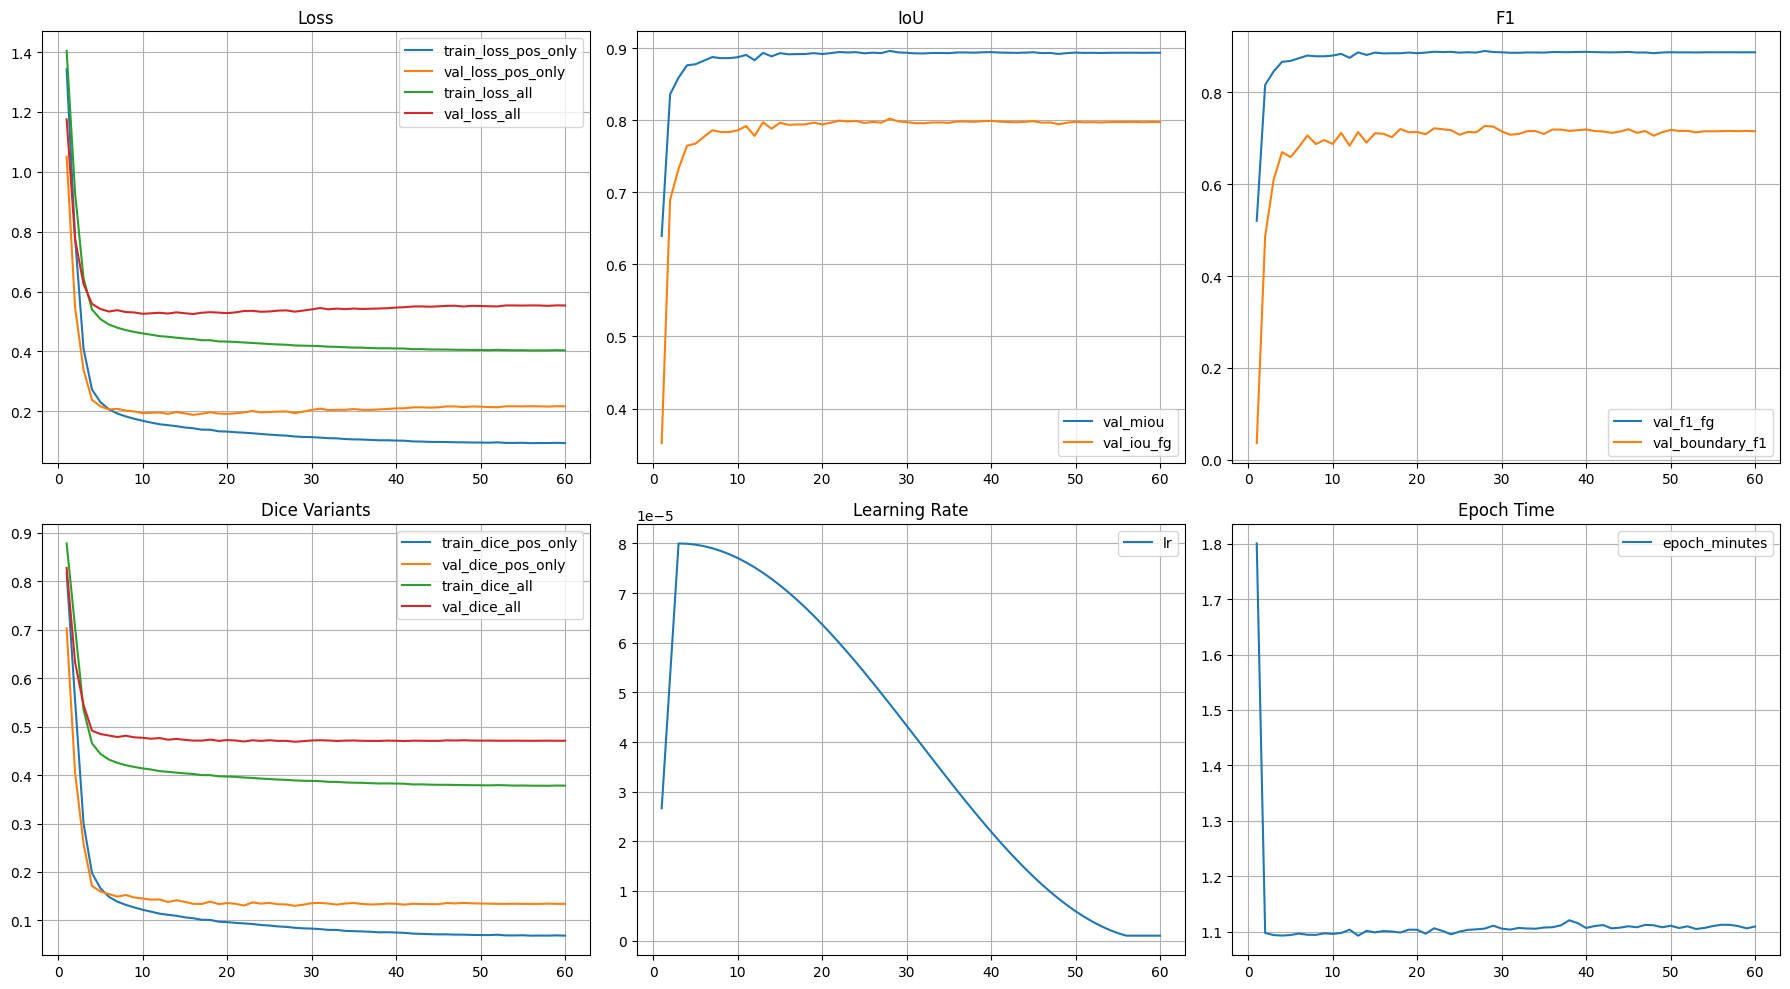

[Output removed: sample tiles from the dataset, which is not public.]



===== EXPERIMENT SUMMARY =====


,run_name,run_tag,model_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,min_lr,...,test_iou_fg,test_f1_fg,test_precision,test_recall,test_boundary_f1,total_params_m,trainable_params_m,inference_ms_per_image,status,run_dir
0,mitb0_A100_0410,mitb0_A100_0410,nvidia/segformer-b0-finetuned-ade-512-512,512,60,32,32,0.00008,0.0001,0.000001,...,0.793454,0.884833,0.898624,0.87146,0.698279,3.714658,3.714658,14.75776,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...



Finished current experiment. Cleaning memory...

Saved multi-run results -> /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_0414_backbone_compare/multi_run_results.csv


,run_name,run_tag,model_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,min_lr,...,test_iou_fg,test_f1_fg,test_precision,test_recall,test_boundary_f1,total_params_m,trainable_params_m,inference_ms_per_image,status,run_dir
0,mitb0_A100_0410,mitb0_A100_0410,nvidia/segformer-b0-finetuned-ade-512-512,512,60,32,32,0.00008,0.0001,0.000001,...,0.793454,0.884833,0.898624,0.87146,0.698279,3.714658,3.714658,14.75776,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...


Found summary files: 6
Saved merged summary -> /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_0414_backbone_compare/all_run_summaries.csv


,run_name,run_tag,model_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,min_lr,...,test_iou_fg,test_f1_fg,test_precision,test_recall,test_boundary_f1,total_params_m,trainable_params_m,inference_ms_per_image,status,run_dir
4,mitb4_A100_0410,mitb4_A100_0410,nvidia/segformer-b4-finetuned-ade-512-512,512,60,16,16,0.00004,0.0001,0.000001,...,0.831119,0.907772,0.911867,0.903713,0.721106,63.994562,63.994562,67.593129,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...
3,mitb3_A100_0410,mitb3_A100_0410,nvidia/segformer-b3-finetuned-ade-512-512,512,60,20,20,0.00006,0.0001,0.000001,...,0.828230,0.906046,0.909574,0.902544,0.720000,47.224002,47.224002,52.618027,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...
5,mitb5_A100_0410,mitb5_A100_0410,nvidia/segformer-b5-finetuned-ade-640-640,512,60,16,16,0.00004,0.0001,0.000001,...,0.827380,0.905537,0.913250,0.897953,0.720559,84.594882,84.594882,87.953496,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...
1,mitb1_A100_0410,mitb1_A100_0410,nvidia/segformer-b1-finetuned-ade-512-512,512,60,28,28,0.00008,0.0001,0.000001,...,0.803070,0.890781,0.895565,0.886048,0.694134,13.677762,13.677762,15.524069,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...
2,mitb2_A100_0410,mitb2_A100_0410,nvidia/segformer-b2-finetuned-ade-512-512,512,60,24,24,0.00006,0.0001,0.000001,...,0.800393,0.889131,0.902388,0.876258,0.705920,27.348162,27.348162,29.864740,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...
0,mitb0_A100_0410,mitb0_A100_0410,nvidia/segformer-b0-finetuned-ade-512-512,512,60,32,32,0.00008,0.0001,0.000001,...,0.793454,0.884833,0.898624,0.871460,0.698279,3.714658,3.714658,14.757760,success,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...


In [14]:
all_results = []

for idx, cfg in enumerate(EXPERIMENTS, 1):
    print("\n" + "#" * 120)
    print(f"Starting experiment {idx}/{len(EXPERIMENTS)}: {cfg['run_tag']}")
    print("#" * 120 + "\n")

    try:
        summary = run_one_experiment(cfg)
        all_results.append(summary)

    except Exception as e:
        print(f"[FAILED] {cfg['run_tag']}")
        traceback.print_exc()

        fail_summary = {
            "run_name": None,
            "run_tag": cfg.get("run_tag", "unknown"),
            "model_name": cfg.get("model_name", "unknown"),
            "image_size": cfg.get("image_size", None),
            "epochs": cfg.get("epochs", None),
            "batch_size": cfg.get("train_batch_size", None),
            "eval_batch_size": cfg.get("eval_batch_size", None),
            "lr": cfg.get("lr", None),
            "weight_decay": cfg.get("weight_decay", None),
            "optimizer": cfg.get("optimizer_name", None),
            "loss_name": cfg.get("loss_name", None),
            "status": "failed",
            "error": str(e),
            "run_dir": str(get_run_dir(cfg)),
        }
        all_results.append(fail_summary)

        fail_path = OUTPUT_ROOT / f"{cfg.get('run_tag', 'unknown')}_failed_summary.json"
        save_json(fail_summary, fail_path)

        cleanup_memory()

    print("\nFinished current experiment. Cleaning memory...\n")
    cleanup_memory()
    time.sleep(5)

results_df = pd.DataFrame(all_results)
results_df_path = OUTPUT_ROOT / "multi_run_results.csv"
results_df.to_csv(results_df_path, index=False)

print("Saved multi-run results ->", results_df_path)
display(results_df)

summary_files = sorted(OUTPUT_ROOT.glob("*/summary.csv"))
print("Found summary files:", len(summary_files))

all_rows = []
for sf in summary_files:
    try:
        df = pd.read_csv(sf)
        if len(df) > 0:
            all_rows.append(df.iloc[0].to_dict())
    except Exception as e:
        print(f"Skip {sf}: {e}")

if len(all_rows) == 0:
    print("No valid summary.csv found.")
else:
    all_df = pd.DataFrame(all_rows)

    if "test_miou" in all_df.columns:
        all_df = all_df.sort_values("test_miou", ascending=False)

    save_path = OUTPUT_ROOT / "all_run_summaries.csv"
    all_df.to_csv(save_path, index=False)

    print("Saved merged summary ->", save_path)
    display(all_df)